# Figs. 9-10 - Coral compartmental model

Coral example: 13-dimensional compartmental model compressed to a 1D
latent space. Two paper figures are covered here:

1. **Fig. 9** - basic Morse graph at the canonical training size
   (`train_500`, seed 0 of `coral_data_scaling`).
2. **Fig. 10** - final-population histograms across training sizes.

`coral_adaptive` (Fig. 11) is not replayable locally; the on-disk
checkpoints from Brittany's archive are zero-byte (see the audit).

In [1]:
import os
os.environ.setdefault('MPLBACKEND', 'module://matplotlib_inline.backend_inline')
%matplotlib inline

import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from IPython.display import Image, display
from latentdynamics.config import load_config
from latentdynamics.training import load_any_checkpoint
from latentdynamics.viz import render_morse_from_files

REPO_ROOT = Path.cwd().resolve().parent  # code/
RENDER_ROOT = Path.cwd() / 'rendered'
RENDER_ROOT.mkdir(exist_ok=True)

DEVICE = (
    torch.device('mps') if torch.backends.mps.is_available()
    else torch.device('cuda') if torch.cuda.is_available()
    else torch.device('cpu')
)
print('device:', DEVICE)

device: mps


In [2]:
def _seed_dir(cfg, seed):
    return REPO_ROOT / cfg.paths.output_dir / f'seed_{seed}'

def _scaler_dir(cfg, train_file='train'):
    return REPO_ROOT / cfg.paths.output_dir / 'scalers' / train_file

def _bounds_from_log(path):
    if not path.exists():
        return None, None
    lower = upper = None
    for line in path.read_text().splitlines():
        k = line.split(':', 1)[0].strip().lower()
        if k == 'lower bounds':
            lower = json.loads(line.split(':', 1)[1])
        elif k == 'upper bounds':
            upper = json.loads(line.split(':', 1)[1])
    return lower, upper

def show(path, width=600):
    display(Image(filename=str(path), width=width))

def load_replay(cfg, seed, train_file='train'):
    seed_dir = _seed_dir(cfg, seed)
    if not seed_dir.exists():
        raise FileNotFoundError(seed_dir)
    model, arch = load_any_checkpoint(seed_dir / 'models', arch=cfg.arch, map_location=DEVICE)
    model.to(DEVICE).eval()
    scaler_path = _scaler_dir(cfg, train_file) / 'scaler.gz'
    scaler = joblib.load(scaler_path) if scaler_path.exists() else None
    return seed_dir, model, arch, scaler

@torch.no_grad()
def encode_batch(model, scaler, x_high):
    x = scaler.transform(x_high) if scaler is not None else x_high
    return model.encoder(torch.as_tensor(x, dtype=torch.float32, device=DEVICE)).cpu().numpy()

@torch.no_grad()
def advance_latent(model, z_low):
    z = torch.as_tensor(z_low, dtype=torch.float32, device=DEVICE)
    return model.latent_map(z).cpu().numpy()

## Fig. 9 - basic coral Morse graph (train_500, seed_0)

In [3]:
cfg = load_config(REPO_ROOT / 'configs' / 'coral_data_scaling.yaml')
TRAIN_FILE = 'train_500'
SEED = 0
seed_dir = REPO_ROOT / cfg.paths.output_dir / TRAIN_FILE / f'seed_{SEED}'
print('seed_dir:', seed_dir)

model, arch = load_any_checkpoint(seed_dir / 'models', arch=cfg.arch, map_location=DEVICE)
model.to(DEVICE).eval()
scaler = joblib.load(REPO_ROOT / cfg.paths.output_dir / 'scalers' / TRAIN_FILE / 'scaler.gz')
print('arch:', arch.high_dims, '->', arch.low_dims)

seed_dir: /Users/bdoprad/Work/Projects/latent-dynamics/code/output/coral_data_scaling/train_500/seed_0


arch: 13 -> 1


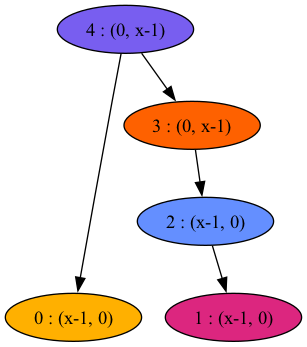

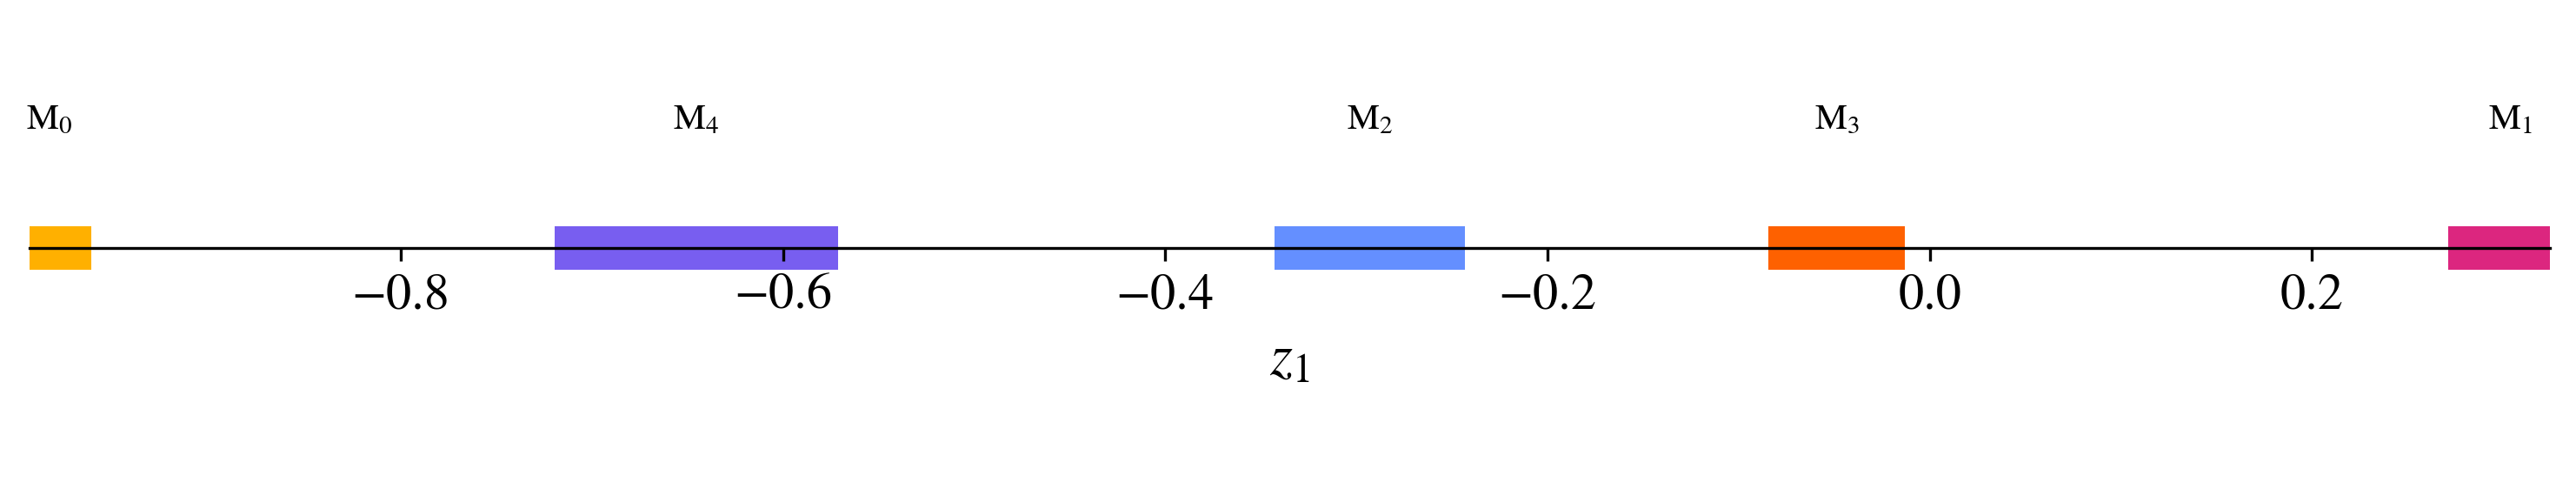

In [4]:
lower, upper = _bounds_from_log(seed_dir / 'mg_params_log.txt')
render_dir = RENDER_ROOT / 'coral_basic'
figs = render_morse_from_files(seed_dir / 'MG', bounds_lower=lower, bounds_upper=upper, out_dir=render_dir)
show(figs.morse_graph_png)
for p in figs.morse_sets_paths:
    if p.suffix == '.png':
        show(p, width=720)

### Latent image of training data (1D)

train rows: 10000 -> latent: (10000, 1)


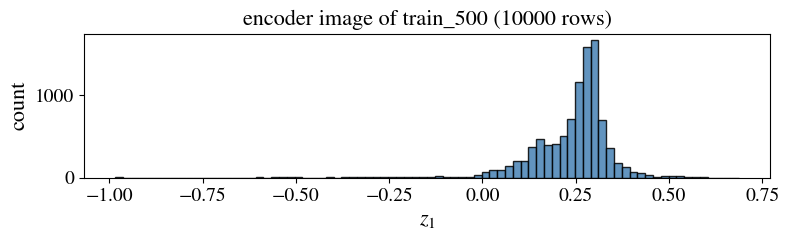

In [5]:
train_df = pd.read_csv(REPO_ROOT / cfg.paths.data_dir / f'{TRAIN_FILE}.csv')
high_cols = [c for c in train_df.columns if c.startswith('x')]
z = encode_batch(model, scaler, train_df[high_cols].to_numpy())
print('train rows:', train_df.shape[0], '-> latent:', z.shape)

fig, ax = plt.subplots(figsize=(8, 2.5))
ax.hist(z[:, 0], bins=80, color='steelblue', edgecolor='black', alpha=0.85)
ax.set_xlabel('$z_1$'); ax.set_ylabel('count')
ax.set_title(f'encoder image of {TRAIN_FILE} ({train_df.shape[0]} rows)')
plt.tight_layout(); plt.show()

## Fig. 10 - final-population histograms across training sizes

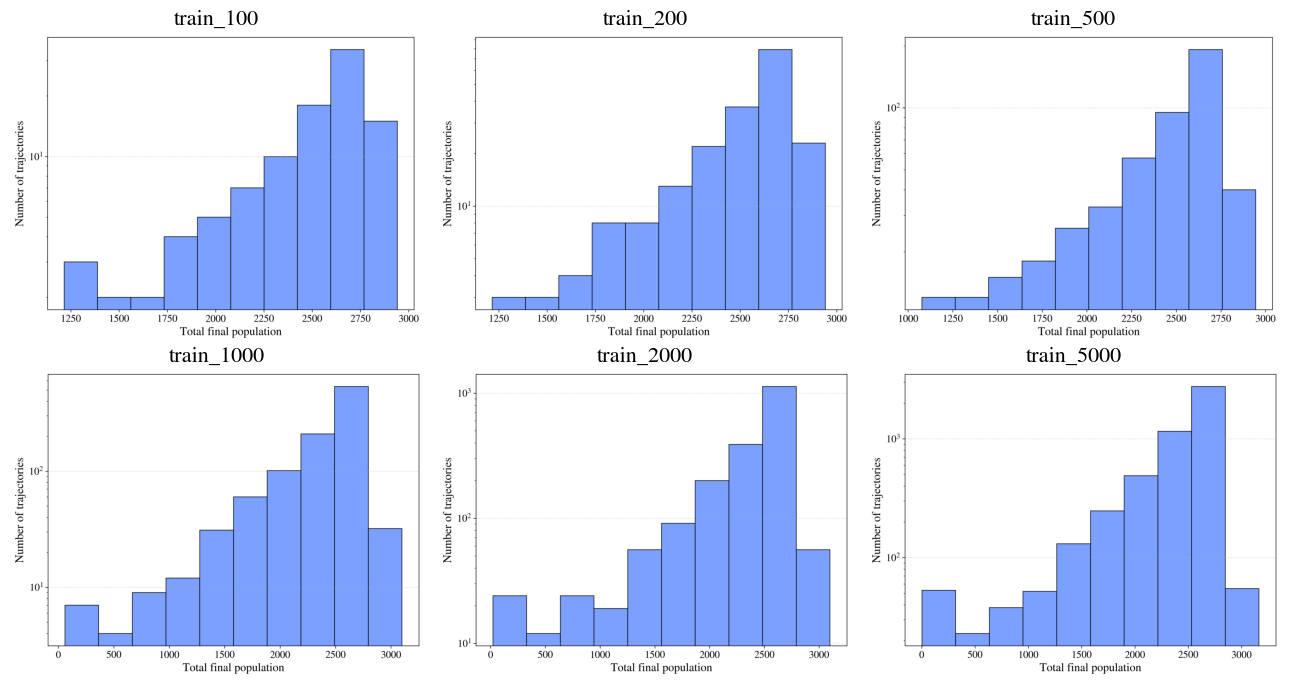

In [6]:
from latentdynamics.viz import plot_final_population_histogram, histograms

out_dir = RENDER_ROOT / 'coral_data_scaling'
out_dir.mkdir(parents=True, exist_ok=True)

data_dir = REPO_ROOT / cfg.paths.data_dir
sizes = ['train_100', 'train_200', 'train_500', 'train_1000', 'train_2000', 'train_5000']
rendered = []
for name in sizes:
    csv = data_dir / f'{name}.csv'
    meta = data_dir / f'{name}_metadata.json'
    if not csv.exists() or not meta.exists():
        continue
    steps = histograms.steps_per_trajectory_from_metadata(meta)
    png = out_dir / f'histogram_{name}.png'
    plot_final_population_histogram(csv, png, steps_per_trajectory=steps)
    rendered.append((name, png))

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, (name, png) in zip(axes.ravel(), rendered):
    ax.imshow(plt.imread(png)); ax.set_title(name); ax.axis('off')
for ax in axes.ravel()[len(rendered):]:
    ax.axis('off')
plt.tight_layout(); plt.show()

## Diagnostics

In [7]:
print('-- mg_params_log.txt --')
print((seed_dir / 'mg_params_log.txt').read_text())
metrics = json.loads((seed_dir / 'metrics.json').read_text() or '{}')
print('-- metrics.json --')
print(json.dumps(metrics, indent=2) if metrics else '(empty)')

-- mg_params_log.txt --
Lower bounds: [-1.001216173171997]
Upper bounds: [0.7852622866630554]
subdiv_init: 6
subdiv_min: 8
subdiv_max: 10
subdiv_limit: 10000
bounds_epsilon_frac: 0.01
padding: True
box_map_backend: auto
bounds_source: encoded_data
duration_minutes: 0.0003

-- metrics.json --
{
  "labels": {
    "a0": 0,
    "a1": 1,
    "r": null
  },
  "metrics": {
    "a0": true,
    "a1": true,
    "r": false
  }
}
